In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import mannwhitneyu

In [153]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['pdf.fonttype'] = 42

# Sanborn explore

In [17]:
# Read in yeast sequences

with open("/Users/claireleblanc/Documents/grad_school/staller_lab/yeast_proteins/saccharomyces_cerevisiae.sgd.pep", "r") as f:
    lines = f.readlines()

seqs = []
names = []
seq = ""

for line in lines:
    if line.startswith(">"):
        names.append(line.replace(">", "").strip())
        if len(names) > 1:
            seqs.append(seq)
            seq = ""
    else:
        seq += line.strip()

seqs.append(seq)

seq_df = pd.DataFrame({'Standard name' : names, 'aa_seq' : seqs})
seq_df

,Standard name,aa_seq
0,YAL068C,MVKLTSIAAGVAAIAATASATTTLAQSDERVNLVELGVYVSDIRAH...
1,YAL067W-A,MPIIGVPRCLIKPFSVPVTFPFSVKKNIRILDLDPRTEAYCLSLNS...
2,YAL067C,MYSIVKEIIVDPYKRLKWGFIPVKRQVEDLPDDLNSTEIVTISNSI...
3,YAL065C,MNSATSETTTNTGAAETTTSTGAAETKTVVTSSISRFNHAETQTAS...
4,YAL064W-B,MAGEAVSEHTPDSQEVTVTSVVCCLDSVVEIGHHVVYSVVTPLIVA...
...,...,...
6029,Q0140,MKLKLLNMILSMMNKTNNNNNIIINNTLDSLMNKKLLLKNMLLDMN...
6030,Q0160,MKNIKKNQVMNLGPNSKLLKEYKSQLIELNIEQFEAGIGLILGDAY...
6031,Q0250,MLDLLRLQLTTFIMNDVPTPYACYFQDSATPNQEGILELHDNIMFY...
6032,Q0255,MIKWTMINIYLLLMFLIIKNNNNNNNYNNITKYNKDMDLYSIQSPY...


In [22]:
key_df = pd.read_table("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Data/SGD_features_original.tab", header=None)
key_df.columns = [
        "Primary SGDID",
        "Feature type",
        "Feature qualifier",
        "Standard name",
        "protein",
        "Alias",
        "Parent feature name",
        "Secondary SGDID",
        "Chromosome",
        "Start_coordinate",
        "Stop_coordinate",
        "Strand",
        "Genetic position",
        "Coordinate version",
        "Sequence version",
        "Description"
    ]

merged = key_df.merge(seq_df, on="Standard name")
names_df = merged[['protein', 'aa_seq']]

In [26]:
paddle_data = pd.read_excel("/Users/claireleblanc/Documents/grad_school/staller_lab/yeast_proteins/PADDLE_AD_list.xlsx")
paddle_data = paddle_data.merge(names_df, on="protein")

In [253]:
paddle_data = paddle_data.rename({"sequence" : "AD_seq"}, axis = 1)
paddle_data['len'] = paddle_data['aa_seq'].str.len()
paddle_data["AD_end"] = paddle_data["stop"] > (paddle_data['len'] - 3)
threshold = 10

paddle_data["final_negative_AD"] = [s[-threshold:].count("D") + s[-threshold:].count("E") for s in paddle_data["AD_seq"]]
paddle_data["final_charged_AD"] = [s[-threshold:].count("D") + s[-threshold:].count("E") for s in paddle_data["AD_seq"]]
paddle_data["final_negative_full"] = [s[-threshold:].count("D") + s[-threshold:].count("E") for s in paddle_data["aa_seq"]]

paddle_data["beginning_negative_AD"] = [s[:threshold].count("D") + s[:threshold].count("E") for s in paddle_data["AD_seq"]]

In [254]:
paddle_data[paddle_data["AD_end"]]["final_negative_AD"].mean()

np.float64(1.880952380952381)

In [ ]:
paddle_data[~paddle_data["AD_end"]]["final_negative_AD"].mean()

np.float64(1.5192307692307692)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


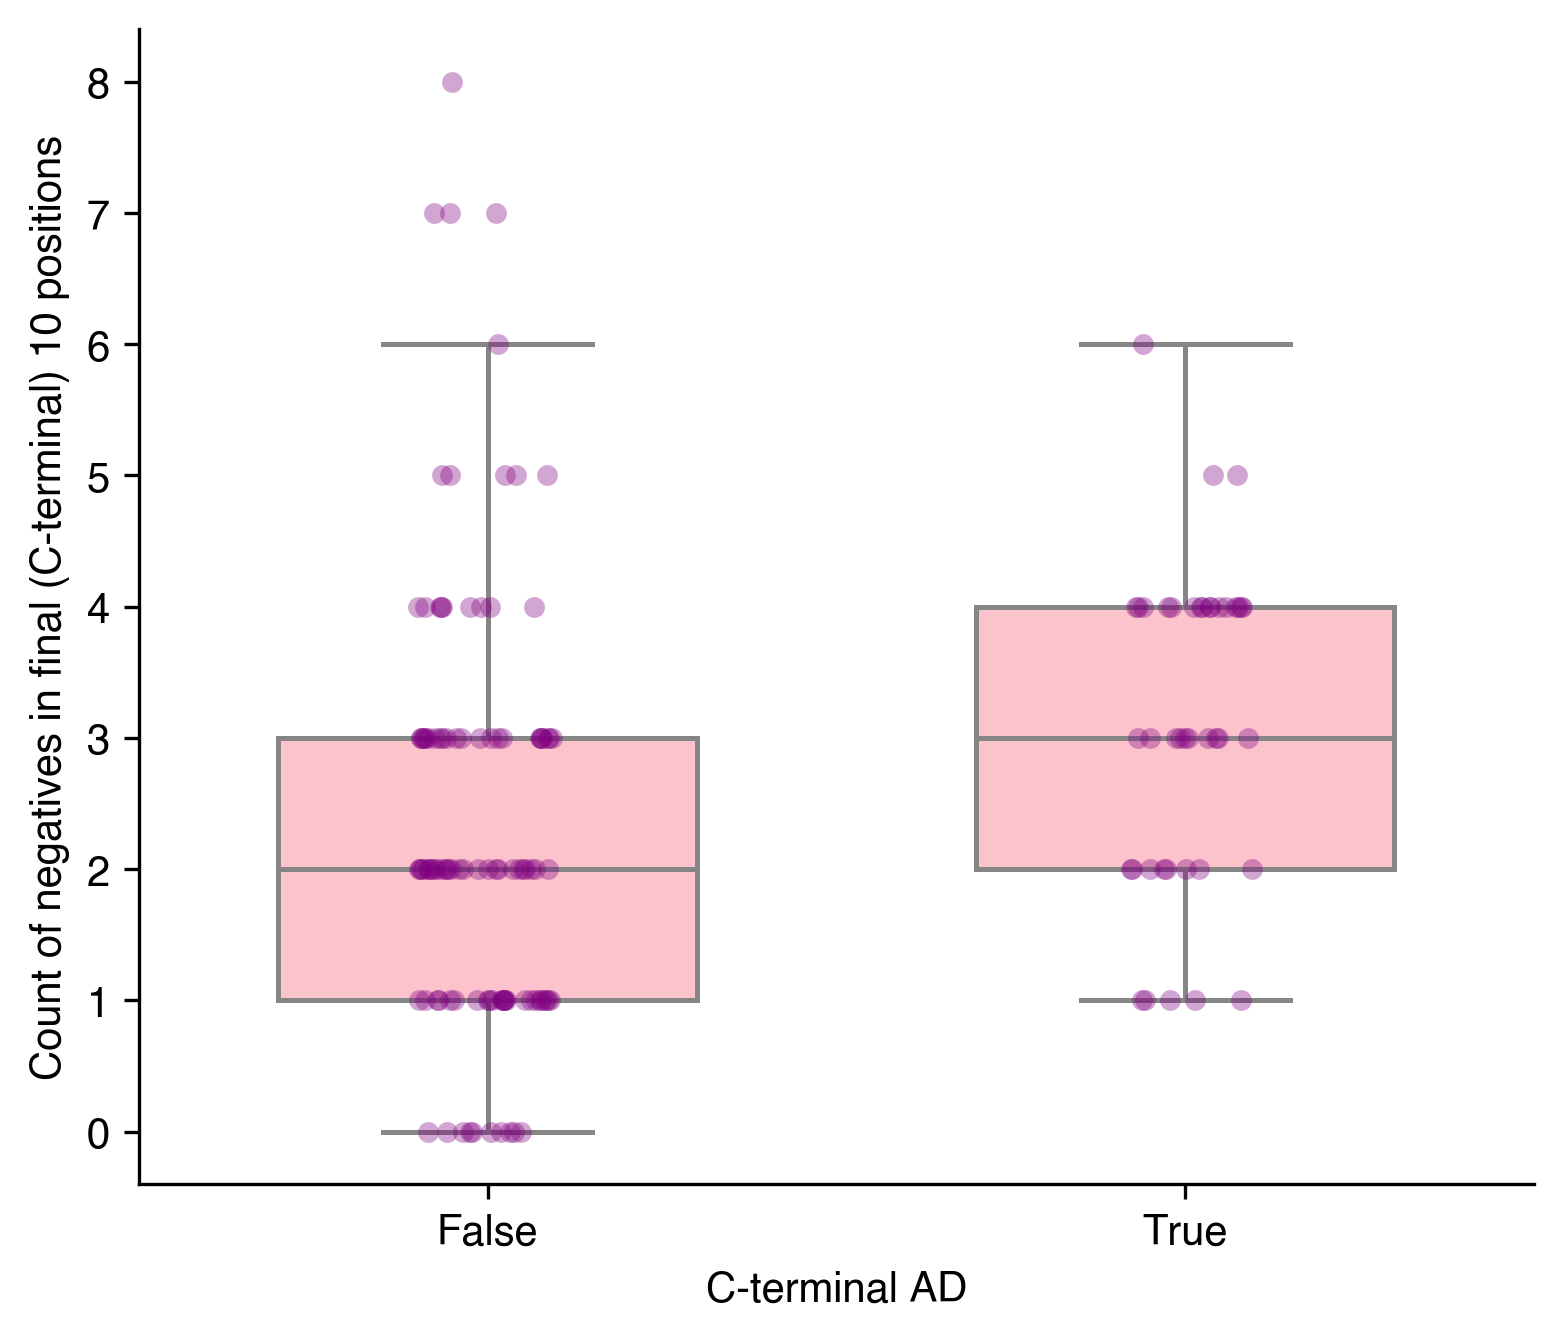

In [232]:
import seaborn as sns
import matplotlib.pyplot as plt

df = paddle_data[["AD_end", "final_negative_AD"]].dropna()
plt.figure(figsize=(6,5))
ax = sns.boxplot(data=df, 
            x="AD_end", 
            y="final_negative_AD", 
            order=[False, True], 
            showfliers=False,
            width=0.6,
            linewidth=1.2,
            whis=1.5,                
            saturation=0.9, 
            color="pink")
sns.stripplot(data=df, x="AD_end", y="final_negative_AD",
              order=[False, True], color="purple", alpha=0.35, jitter=0.1)  # optional dots
plt.xlabel("C-terminal AD")
plt.ylabel("Count of negatives in final (C-terminal) 10 positions")

sns.despine()
plt.savefig("../../figures/C_term_ADs_explore.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../../figures/C_term_ADs_explore.png", format='png', bbox_inches='tight')

In [233]:
# There is a difference between disordered and not (C-terminal)
group1 = paddle_data[paddle_data["AD_end"]]["final_negative_AD"]
group2 = paddle_data[~paddle_data["AD_end"]]["final_negative_AD"]
stat, p = mannwhitneyu(group1, group2, alternative="greater") 
p

np.float64(0.00031238825861303656)

In [234]:
# There is a difference between disordered and not (C-terminal)
group1 = paddle_data[paddle_data["AD_end"]]["beginning_negative_AD"]
group2 = paddle_data[~paddle_data["AD_end"]]["beginning_negative_AD"]
stat, p = mannwhitneyu(group1, group2) 
p

np.float64(0.5594295772623668)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


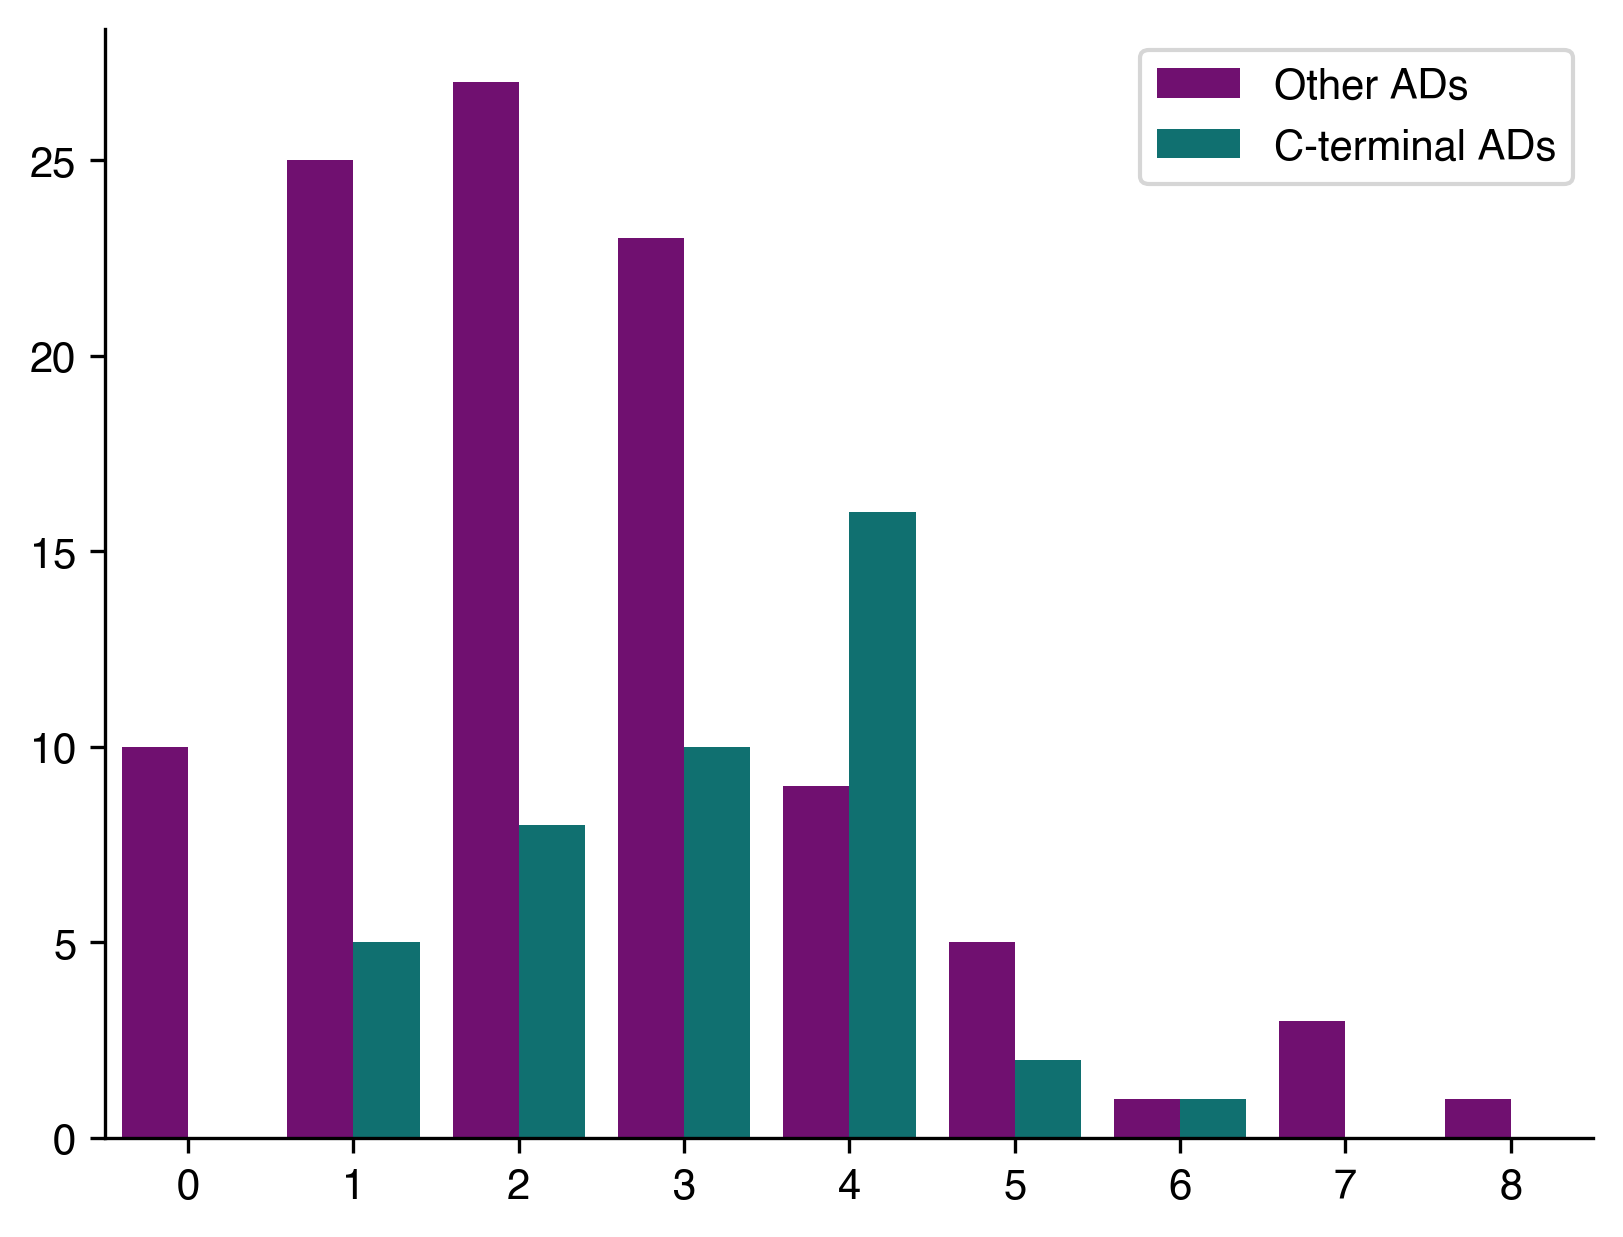

In [235]:
no_ad = paddle_data[~paddle_data["AD_end"]]["final_negative_AD"].value_counts()
ad = paddle_data[paddle_data["AD_end"]]["final_negative_AD"].value_counts()

x = np.concatenate([no_ad.index.values, ad.index.values])
y = np.concatenate([no_ad, ad])
hue = ["Other ADs"] * len(no_ad) + ["C-terminal ADs"] * len(ad)

# #plt.bar(x=paddle_merged[paddle_merged["AD_end"]]["final_negative_full"].value_counts().index, height=paddle_merged[paddle_merged["AD_end"]]["final_negative_full"].value_counts(), alpha=0.5)
# ax = plt.subplot(111)
# ax.bar(x, y, width=0.2, align='center')
# ax.bar(x=paddle_merged[paddle_merged["AD_end"]]["final_negative_full"].value_counts().index, height=paddle_merged[paddle_merged["AD_end"]]["final_negative_full"].value_counts(), alpha=0.5, width=0.2, align='center')
# ax.autoscale(tight=True)

sns.barplot(x=x, y=y, hue=hue, palette=['purple', 'teal'])
sns.despine()

plt.savefig("../../figures/C_term_ADs_hist.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../../figures/C_term_ADs_hist.png", format='png', bbox_inches='tight')

In [237]:
# There is a difference between disordered and not (C-terminal)
group1 = paddle_data[paddle_data["AD_end"]]["final_hydro"]
group2 = paddle_data[~paddle_data["AD_end"]]["final_hydro"]
stat, p = mannwhitneyu(group1, group2) 
p

np.float64(0.7555514284442119)

In [209]:
paddle_data.columns

Index(['protein', 'protein ID', 'start', 'stop', 'maximal activation',
       'maximal Z score', 'maximal fragment', 'AD_seq', 'aa_seq', 'len',
       'AD_end', 'final_negative_AD', 'final_negative_full',
       'beginning_negative_AD', 'charges', 'charges_full', 'final_charged_AD',
       'final_negative_hydro', 'final_hydro'],
      dtype='object')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


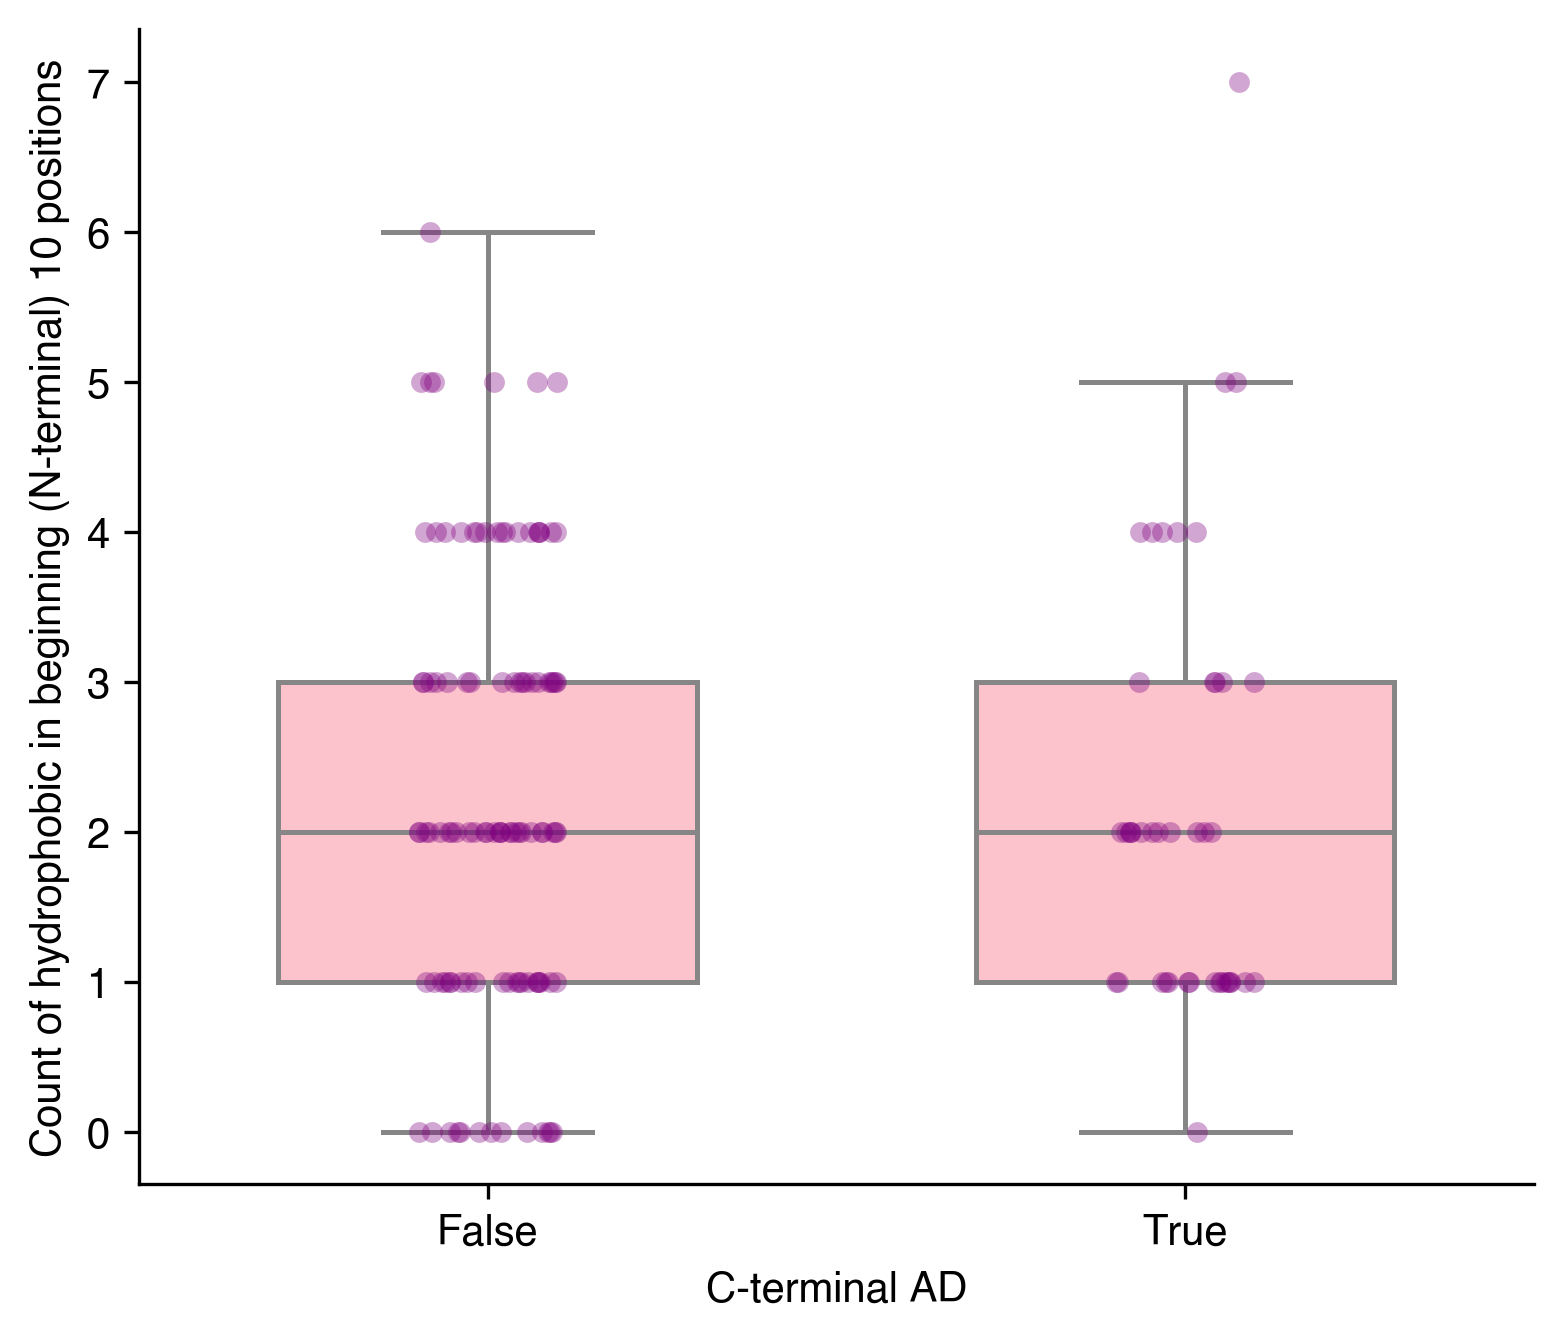

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = paddle_data[["AD_end", "beginning_negative_AD"]].dropna()
plt.figure(figsize=(6,5))
ax = sns.boxplot(data=df, 
            x="AD_end", 
            y="beginning_negative_AD", 
            order=[False, True], 
            showfliers=False,
            width=0.6,
            linewidth=1.2,
            whis=1.5,                
            saturation=0.9, 
            color="pink")
sns.stripplot(data=df, x="AD_end", y="beginning_negative_AD",
              order=[False, True], color="purple", alpha=0.35, jitter=0.1)  # optional dots
plt.xlabel("C-terminal AD")
plt.ylabel("Count of negative in beginning (N-terminal) 10 positions")

sns.despine()
plt.savefig("../../figures/N_term_negatives.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../../figures/N_term_negatives.png", format='png', bbox_inches='tight')

In [243]:
np.finfo(np.float64)

finfo(resolution=1e-15, min=-1.7976931348623157e+308, max=1.7976931348623157e+308, dtype=float64)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


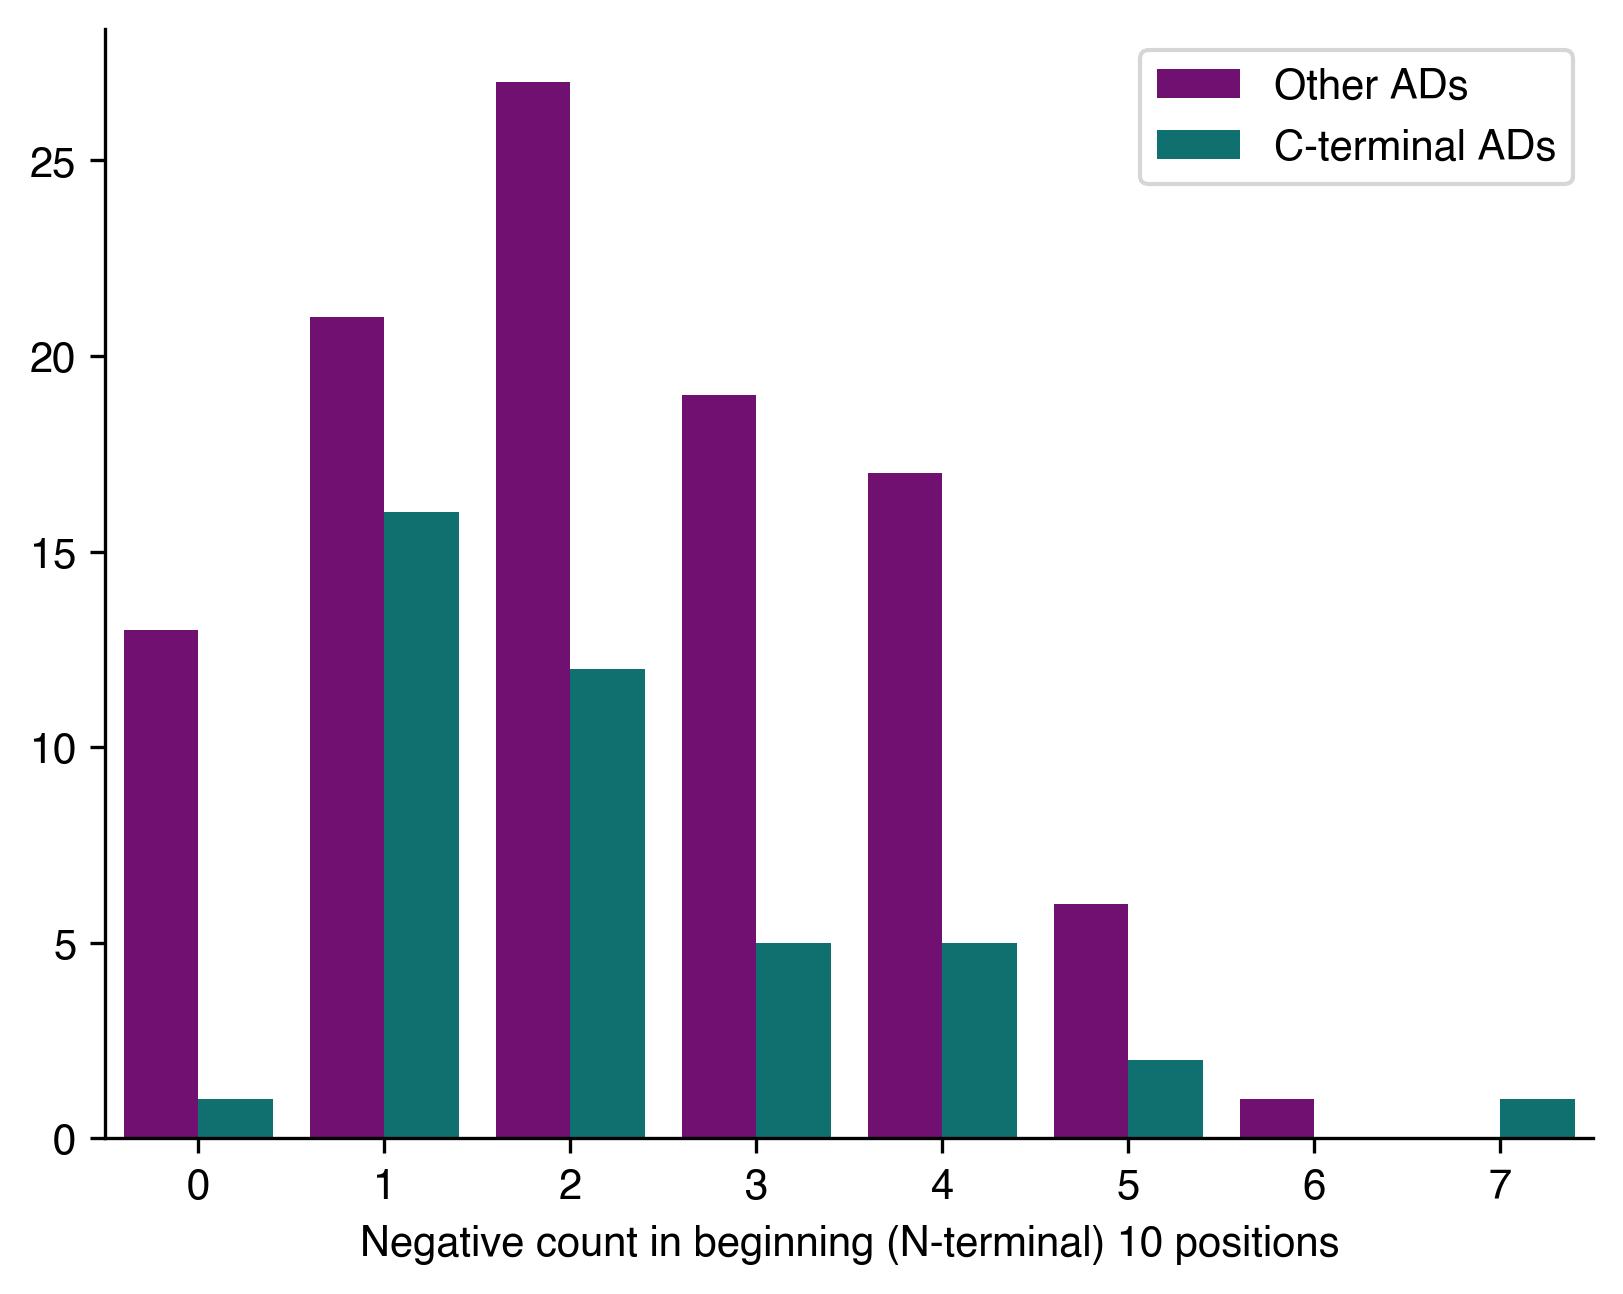

In [ ]:
no_ad = paddle_data[~paddle_data["AD_end"]]["beginning_negative_AD"].value_counts()
ad = paddle_data[paddle_data["AD_end"]]["beginning_negative_AD"].value_counts()

x = np.concatenate([no_ad.index.values, ad.index.values])
y = np.concatenate([no_ad, ad])
hue = ["Other ADs"] * len(no_ad) + ["C-terminal ADs"] * len(ad)

sns.barplot(x=x, y=y, hue=hue, palette=['purple', 'teal'])
sns.despine()

plt.xlabel("Negative count in beginning (N-terminal) 10 positions")
plt.savefig("../../figures/N_term_negatives_hist.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../../figures/N_term_negatives_hist.png", format='png', bbox_inches='tight')

# Other random exploratory code

In [44]:
def charge(seq, window=10):
    charges = []
    for i in range(len(seq) - window+1):
        charges.append((seq[i:i+window].count("D") + seq[i:i+window].count("E"))/window)

    return charges

In [45]:
paddle_data["charges"] = [charge(s) for s in paddle_data["AD_seq"]]
paddle_data["charges"] = [[(s == "D") or (s == "E") for s in seq] for seq in paddle_data["AD_seq"]]
paddle_data["charges_full"] = [[(s == "D") or (s == "E") for s in seq] for seq in paddle_data["aa_seq"]]

In [46]:
paddle_data["AD_end"].value_counts()

AD_end
False    104
True      42
Name: count, dtype: int64

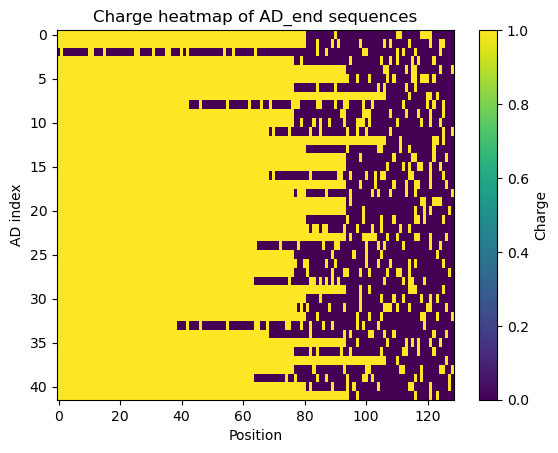

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the charges into a 2D array
charges = paddle_data[paddle_data["AD_end"]]["charges"].values
# Find maximum length
max_len = max(len(arr) for arr in charges)

# Pad each array from the front
padded = []
for arr in charges:
    pad_width = max_len - len(arr)
    padded_arr = np.pad(arr, (pad_width, 0), mode="constant", constant_values=np.nan)
    padded.append(padded_arr)

charges_array = np.vstack(padded)

# Plot as heatmap
plt.imshow(charges_array, aspect="auto")  # red/blue colormap
plt.colorbar(label="Charge")
plt.xlabel("Position")
plt.ylabel("AD index")
plt.title("Charge heatmap of AD_end sequences")
plt.show()


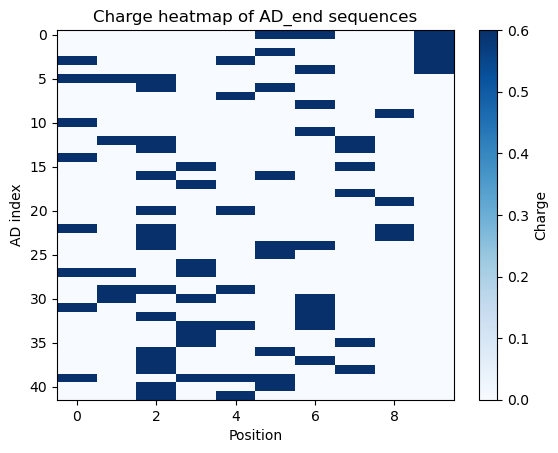

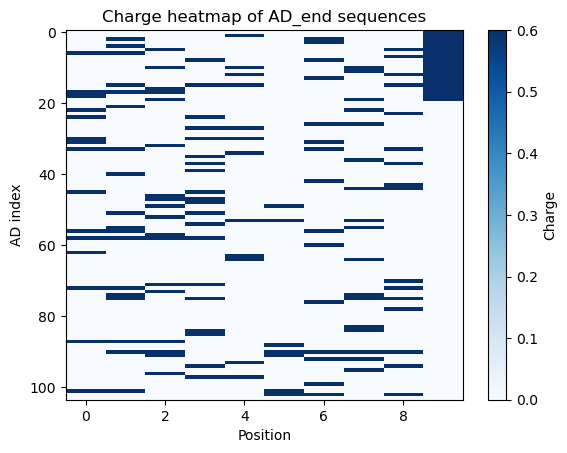

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the charges into a 2D array
charges = paddle_data[paddle_data["AD_end"]]["charges"].values
# Find maximum length
# max_len = max(len(arr) for arr in charges)

# Pad each array from the front
padded = []
for arr in charges:
    padded_arr = arr[-10:]
    padded.append(padded_arr)

charges_array = np.vstack(padded)

last_vals = np.nan_to_num(charges_array[:, -1], nan=-np.inf)
order = np.argsort(~last_vals)
charges_array = charges_array[order]

# Plot as heatmap
plt.imshow(charges_array, aspect="auto", vmax=0.6, vmin=0, cmap='Blues')  # red/blue colormap
plt.colorbar(label="Charge")
plt.xlabel("Position")
plt.ylabel("AD index")
plt.title("Charge heatmap of AD_end sequences")
plt.show()

# Extract the charges into a 2D array
charges = paddle_data[~paddle_data["AD_end"]]["charges"].values
# Find maximum length
max_len = max(len(arr) for arr in charges)

# Pad each array from the front
padded = []
for arr in charges:
    padded_arr = arr[-10:]
    padded.append(padded_arr)

charges_array = np.vstack(padded)
last_vals = np.nan_to_num(charges_array[:, -1], nan=-np.inf)
order = np.argsort(~last_vals)
charges_array = charges_array[order]

# Plot as heatmap
plt.imshow(charges_array, aspect="auto", vmax=0.6, vmin=0, cmap='Blues')  # red/blue colormap
plt.colorbar(label="Charge")
plt.xlabel("Position")
plt.ylabel("AD index")
plt.title("Charge heatmap of AD_end sequences")
plt.show()


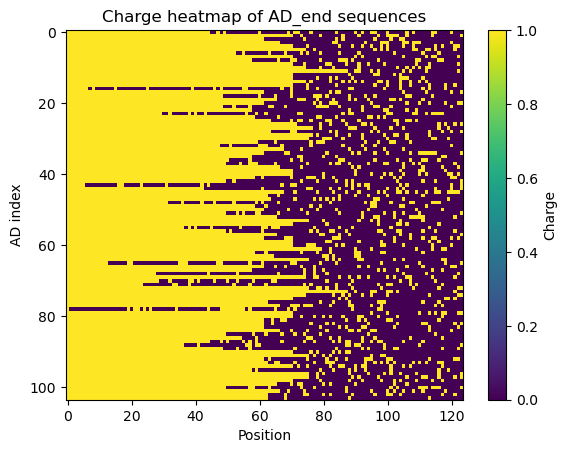

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the charges into a 2D array
charges = paddle_data[~paddle_data["AD_end"]]["charges"].values
# Find maximum length
max_len = max(len(arr) for arr in charges)

# Pad each array from the front
padded = []
for arr in charges:
    pad_width = max_len - len(arr)
    padded_arr = np.pad(arr, (pad_width, 0), mode="constant", constant_values=np.nan)
    padded.append(padded_arr)

charges_array = np.vstack(padded)

# Plot as heatmap
plt.imshow(charges_array, aspect="auto")  # red/blue colormap
plt.colorbar(label="Charge")
plt.xlabel("Position")
plt.ylabel("AD index")
plt.title("Charge heatmap of AD_end sequences")
plt.show()

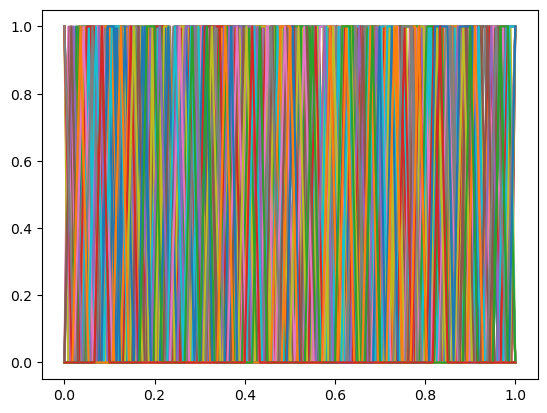

In [50]:
for ls in paddle_data[~paddle_data["AD_end"]]["charges"]:
    plt.plot(np.linspace(0, 1, num=len(ls)), ls)